# Toddler Project: Joins
- I will be merging my women_in_stem dataset from my baby project to another dataset (GDP per capita)
- This dataset was found on worldbank: https://data.worldbank.org/indicator/NY.GDP.PCAP.CD 
- These two datasets share the common column of Year & Country

## Importing Packages

In [1]:
import pandas as pd
import os

In [2]:
os.getcwd() ## where my notebook is working from

'C:\\Users\\ashle\\Desktop\\women_in_stem_data_analysis\\scripts'

## Looking at women_in_stem dataset
- This dataset was found on kaggle: https://www.kaggle.com/datasets/bismasajjad/womens-representation-in-global-stem-education
- This dataset lives in the data file

In [3]:
stem = pd.read_csv("../data/women_in_stem.csv")
stem.head()

,Country,Year,Female Enrollment (%),Female Graduation Rate (%),STEM Fields,Gender Gap Index
0,China,2018,20.4,43.2,Engineering,0.52
1,China,2005,35.6,29.3,Mathematics,0.98
2,China,2005,53.7,32.4,Biology,0.60
3,Germany,2007,65.0,63.6,Mathematics,0.69
4,Canada,2010,54.4,28.8,Engineering,0.74


## Quick clean!
- Before merging, I want to ensure the primary dataset (in this case, women_in_stem) is the right datatype
- Country as a string, Year as an int

In [4]:
## Country into a string
stem["Country"] = stem["Country"].astype(str).str.strip() ## remove spaces if applicable 

## Year as integer
stem["Year"] = stem["Year"].astype(int)

### Saving this to my clean_data folder

In [5]:
stem.to_csv("../clean_data/stem_clean.csv", index = False) ## to clean_data folder

## GDP Dataset!
- This will be the secondary dataset that will be merged with women in stem

### Structuring the Dataset
- The format of this dataset is different
- years are listed horizontally as a row rather than a column
- The data also doesn't start until the fourth row of the file

In [6]:
gdp_raw = pd.read_csv("../data/gdp_country.csv", skiprows = 4) ## skipping 4 rows to the data
gdp_raw.head() ## display

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,27441.550214,28440.041688,30082.158423,30645.890602,22759.807175,26749.329609,30975.998912,35718.753119,39498.594129,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089204,186.909053,197.367547,225.400079,208.962717,226.836135,...,1334.470500,1528.104224,1552.073722,1507.085600,1351.591669,1562.416175,1679.327622,1571.449189,1615.396356,NaN
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,522.082216,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.545883,155.561897,...,1630.039439,1574.230564,1720.140092,2216.385055,2030.861659,2112.794076,2138.473153,1841.855064,1411.337029,NaN
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2051.814621,2790.718869,2860.093648,2493.678844,1759.356199,2303.908127,3682.113151,2916.136633,2665.874448,NaN


In [7]:
id_cols = ["Country Name", "Country Code", "Indicator Name", "Indicator Code"]

gdp_long = gdp_raw.melt( ##using melt() to fix the structure to match the women_in_stem 
    id_vars=id_cols,
    var_name = "Year",
    value_name = "gdp_per_capita_usd"
)

gdp_long = gdp_long[gdp_long["Year"].astype(str).str.fullmatch(r"\d{4}")] ## keeps rows that have 4 digits (this ensures the year) e.g 2016
gdp_long["Year"] = gdp_long["Year"].astype(int) ## ensuring type

gdp_long = gdp_long.rename(columns ={"Country Name": "Country"}) ## renaming the Country Name column to Country to match women_in_stem

gdp_long[["Country", "Year", "gdp_per_capita_usd"]].head() 

,Country,Year,gdp_per_capita_usd
0,Aruba,1960,NaN
1,Africa Eastern and Southern,1960,186.089204
2,Afghanistan,1960,NaN
3,Africa Western and Central,1960,121.936832
4,Angola,1960,NaN


Now the GDP dataset is of similar structure as women in stem dataset

## AI Disclosure

I used AI (Perplexity) to assist me with this block of code:

gdp_long = gdp_raw.melt( 
    id_vars=id_cols,
    var_name = "Year",
    value_name = "gdp_per_capita_usd"
)

I opened the CSV file before creating this notebook and realized the structure was different. 

I wanted to understand the melt() function and ensure that it is being used properly to structure the dataset before merging

AI prompt: 
"Can you explain how I can use melt()to convert wide format dataset worldbank, the years are columns, to long formatso that I can use country and year as keys in a merge."

## Merging

Taking a look at the stem_clean before merging
- This is important as I make sure Columns are correct, naming is correct, before I try to join the 2 datasets
- Earlier, I did some slight cleaning too so making sure it looks good to join

In [8]:
stem_clean = pd.read_csv("../clean_data/stem_clean.csv")
stem_clean.head() ## display

,Country,Year,Female Enrollment (%),Female Graduation Rate (%),STEM Fields,Gender Gap Index
0,China,2018,20.4,43.2,Engineering,0.52
1,China,2005,35.6,29.3,Mathematics,0.98
2,China,2005,53.7,32.4,Biology,0.60
3,Germany,2007,65.0,63.6,Mathematics,0.69
4,Canada,2010,54.4,28.8,Engineering,0.74


### Left Join
- Merging left join, this ensures data from my primary dataset (women_in_stem) is preserved
- If there isnt a match with the secondary data set, there will be a NaN value, but data remains from the primary

In [9]:
## primary: women_in_stem
## secondary: GDP
stem_gdp_join = pd.merge(
    stem_clean, 
    gdp_long[["Country", "Year", "gdp_per_capita_usd"]],
    on=["Country", "Year"], ## compound key
    how="left",
    indicator = True ## show _merge column
)

stem_gdp_join.head()

,Country,Year,Female Enrollment (%),Female Graduation Rate (%),STEM Fields,Gender Gap Index,gdp_per_capita_usd,_merge
0,China,2018,20.4,43.2,Engineering,0.52,10085.663815,both
1,China,2005,35.6,29.3,Mathematics,0.98,1777.644968,both
2,China,2005,53.7,32.4,Biology,0.60,1777.644968,both
3,Germany,2007,65.0,63.6,Mathematics,0.69,42350.921721,both
4,Canada,2010,54.4,28.8,Engineering,0.74,47560.666601,both


## Explain: 

I decided to use a left join when combining these datasets. Women_in_stem was my primary dataset, and the GDP data was my secondary dataset. I wanted to preserve all my data from my primary source, since that is what I originally analyzed in the Baby project. Left joins are safer because they preserve all the data from the primary, even if there's no match with the secondary set (in this case, it would return a NaN when applicable). Adding the GDP data was additional, and so I only needed the GDP data for the countries and years that exist in my primary set. This ensures data isnt silently dropped from my primary set. I also used a compound key connecting with both Country and Year, as those columns were in both datasets. Because of this, NaN may appear when there isnt a match with both country and year in the secondary dataset. 

## Checking the merge

In [10]:
stem_gdp_join["_merge"].value_counts() ## show how many per each merge type when the merge happened

_merge
both          418
left_only      82
right_only      0
Name: count, dtype: int64

- 418 rows successfuly merged with the secondary dataset
- 82 rows didnt have a match
  
Confirms that the primary dataset was preserved in the merge

# Saving the new dataset

In [11]:
stem_gdp_join.to_csv("../clean_data/stem_gdp_join.csv", index = False)

# Some Analysis!

### Import Packages

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
analysis_df = stem_gdp_join.dropna(subset=["gdp_per_capita_usd"]).copy() ## making a copy

### Column Check
- check columns since I merged the datasets

In [14]:
analysis_df.columns ## column display

Index(['Country', 'Year', 'Female Enrollment (%)',
       'Female Graduation Rate (%)', 'STEM Fields', 'Gender Gap Index',
       'gdp_per_capita_usd', '_merge'],
      dtype='object')

## Correlation
- Correlation check with columns female enrollment and gdp

In [15]:
analysis_df[["gdp_per_capita_usd", "Female Enrollment (%)"]].dtypes ## checking datatypes before working with these two columns

gdp_per_capita_usd       float64
Female Enrollment (%)    float64
dtype: object

### Female Enrollment (%) & GDP
- analyzing a possible correlation

In [16]:
analysis_df["Female Enrollment (%)"].corr(analysis_df["gdp_per_capita_usd"])

np.float64(0.019269860746361937)

- There is no linear relationship between female enrollment % and GDP 

### Graph: Female Enrollment % vs GDP
- visual representation of the correlation through a scatter plot with a regression line

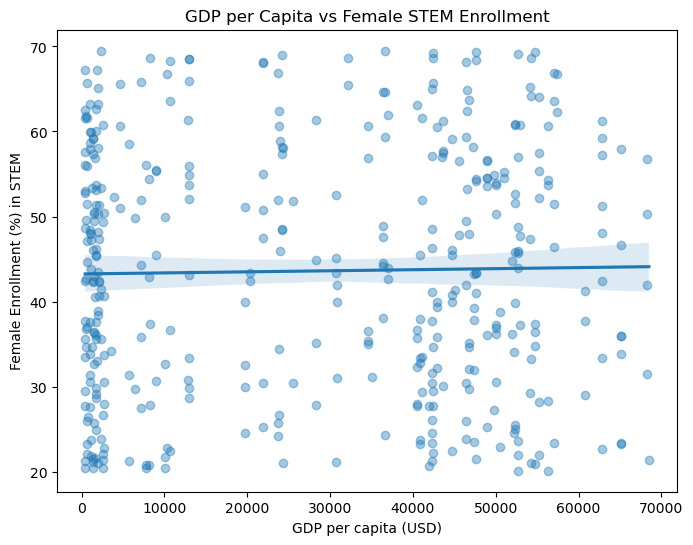

In [17]:
plt.figure(figsize=(8, 6)) ## sizing

## Creating a scatter plot with a regression line
sns.regplot(
    data=analysis_df,
    x = "gdp_per_capita_usd",
    y = "Female Enrollment (%)",
    scatter_kws={"alpha":0.4}
)

## labels
plt.xlabel("GDP per capita (USD)")
plt.ylabel("Female Enrollment (%) in STEM")
plt.title("GDP per Capita vs Female STEM Enrollment")

plt.show()

- Similarly to the correlation call this graph visually represents the same outcome
- the line is flat indicating no linear relationship between GDP and female enrollment

### Gender Gap Index & GDP
-checking correlation

In [18]:
analysis_df[["Gender Gap Index", "gdp_per_capita_usd"]].corr()

,Gender Gap Index,gdp_per_capita_usd
Gender Gap Index,1.000000,0.053905
gdp_per_capita_usd,0.053905,1.000000


- Values are close to 0
- This also indicates there is no linear relationship between gender gap index and GDP

## Income & Female Enrollment
- quartile-based comparison

#### Dividing GDP in groups

In [19]:
analysis_df["income_group"] = pd.qcut( ## dividing into equal-sized groups
    analysis_df["gdp_per_capita_usd"], ## using this column
    q=4, ## 4 equal-sized groups
    labels = ["Low", "Lower-Middle", "Upper-Middle", "Upper"]
)

#### Grouping Female Enrollment by Income group
- Then calculating mean

In [20]:
analysis_df.groupby("income_group", observed = False)["Female Enrollment (%)"].mean()

income_group
Low             43.463551
Lower-Middle    43.417308
Upper-Middle    43.133333
Upper           44.339048
Name: Female Enrollment (%), dtype: float64

- Female enrollment is similar amongst all income groups
- this indicates that Female STEM enrollment is the same across these levels
- There is no strong trend as income increases

To conclude, GDP and female enrollment % are weakly related